# CA-BiLSTM — Lick Classification from Marmoset Cerebellar Recordings
**Data:** Hage et al., PLOS Biology 2025  
**Architecture:** Channel-Attention BiLSTM (ZhangYH321/CA-BiLSTM)  

### Features per lick (T=30 × C=9)
| Ch | Description |
|----|-------------|
| 0–1 | SS spike counts, neuron 1 & 2 (20 ms bins, −200 to +400 ms) |
| 2–3 | CS spike counts, neuron 1 & 2 |
| 4–8 | Kinematics: duration, vm_max, vm_min, dm_max, ang_max |

### Labels
| 0 groom | 1 inner_tube_success | 2 inner_tube_fail | 3 outer_edge_success |
| 4 outer_edge_fail | 5 under_tube_success | 6 under_tube_fail |

In [2]:
# Install h5py if not already available (Kaggle has it, but just in case)
!pip install h5py -q

In [1]:
# ════════════════════════════════════════════════════════════════
# CONFIG — edit paths and hyperparameters here
# ════════════════════════════════════════════════════════════════
CONFIG = {
    # ── data ─────────────────────────────────────────────────────
    # Update these paths to wherever you placed the .mat files
    'mat_paths':            ['/kaggle/input/datasets/mahama5if/pc-spikes/1D_1.mat','/kaggle/input/datasets/mahama5if/pc-spikes/1D_2.mat'],
    # Add '1D_2.mat' once available:
    # 'mat_paths':          ['/kaggle/input/your-dataset/1D_1.mat',
    #                        '/kaggle/input/your-dataset/1D_2.mat'],
    'val_size':             0.15,
    'test_size':            0.15,
    'seed':                 42,
    # ── model ─────────────────────────────────────────────────────
    'input_size':           9,       # 4 spike channels + 5 kinematic channels
    'hidden_size':          128,     # BiLSTM hidden units per direction
    'n_layers':             2,       # stacked BiLSTM layers
    'n_classes':            7,
    'dropout':              0.3,
    'ca_reduction':         2,       # SE bottleneck ratio
    # ── training ─────────────────────────────────────────────────
    'batch_size':           64,
    'epochs':               80,
    'lr':                   3e-4,
    'weight_decay':         1e-4,
    'grad_clip':            1.0,
    'use_class_weights':    True,    # weighted CE loss for imbalance
    'use_weighted_sampler': True,    # oversample minority classes
    # ── output ───────────────────────────────────────────────────
    'save_dir':             '/kaggle/working/checkpoints',
    'log_every':            5,
}
# ════════════════════════════════════════════════════════════════

In [2]:
import os, time, json
import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              balanced_accuracy_score)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

LABEL_NAMES = [
    "groom",
    "inner_tube_success", "inner_tube_fail",
    "outer_edge_success", "outer_edge_fail",
    "under_tube_success", "under_tube_fail",
]
N_CLASSES  = 7
WINDOW_PRE = 0.20   # seconds before lick onset
WINDOW_POST= 0.40   # seconds after  lick onset
BIN_SIZE   = 0.020  # 20 ms bins
N_BINS     = int(round((WINDOW_PRE + WINDOW_POST) / BIN_SIZE))  # 30
print(f"N_BINS: {N_BINS}")

Device: cuda
N_BINS: 30


## Data Loading
Builds per-lick spike PSTHs for both Purkinje cells in each session and assembles the final feature tensor.

In [3]:
# ── Spike PSTH ────────────────────────────────────────────────────────────────
def _spike_psth(spike_times, lick_onsets):
    """(N_licks, N_BINS) spike-count array per 20 ms bin."""
    bins = np.linspace(-WINDOW_PRE, WINDOW_POST, N_BINS + 1)
    psth = np.zeros((len(lick_onsets), N_BINS), dtype=np.float32)
    for i, onset in enumerate(lick_onsets):
        t_rel = spike_times - onset
        mask  = (t_rel >= -WINDOW_PRE) & (t_rel <= WINDOW_POST)
        psth[i], _ = np.histogram(t_rel[mask], bins=bins)
    return psth



def _find_spike_pair(refs, lick_key):
    onsets     = refs[f'{lick_key}/time_onset'][()].flatten()
    lick_start, lick_end = onsets[0], onsets[-1]

    all_spike_keys = [
        k for k in refs
        if hasattr(refs[k], 'keys')
        and 'SS_time' in refs[k]
        and 'CS_time' in refs[k]
    ]

    # Score every key by overlap with lick window
    scored = []
    for k in all_spike_keys:
        ss = refs[f'{k}/SS_time'][()].flatten()
        overlap_direct = int(((ss >= lick_start) & (ss <= lick_end)).sum())
        scored.append((k, overlap_direct, ss[0]))

    # Sort by direct overlap descending
    scored.sort(key=lambda t: -t[1])

    # If NO cell overlaps directly, fall back to offset alignment
    if scored[0][1] == 0:
        # Use first-spike offset to align all cells to absolute time
        ref_start = scored[0][2]  # first spike of best candidate
        rescored = []
        for k, _, ss0 in scored:
            ss = refs[f'{k}/SS_time'][()].flatten()
            offset = ref_start - ss0
            ss_c = ss + offset
            ov = int(((ss_c >= lick_start) & (ss_c <= lick_end)).sum())
            rescored.append((k, offset, ov))
        rescored.sort(key=lambda t: -t[2])
        key_n1, off_n1 = rescored[0][0], rescored[0][1]
        key_n2 = rescored[1][0] if len(rescored) > 1 else key_n1
        off_n2 = rescored[1][1] if len(rescored) > 1 else off_n1
        return key_n1, off_n1, key_n2, off_n2

    # Normal case: at least one cell overlaps directly
    key_n1, off_n1 = scored[0][0], 0.0
    abs_start = refs[f'{key_n1}/SS_time'][()].flatten()[0]

    # Find best second cell
    remaining = scored[1:]
    if remaining:
        rel_pairs = []
        for k, direct_ov, ss0 in remaining:
            if direct_ov > 0:
                rel_pairs.append((k, 0.0, direct_ov))
            else:
                ss = refs[f'{k}/SS_time'][()].flatten()
                offset = abs_start - ss0
                ss_c = ss + offset
                ov = int(((ss_c >= lick_start) & (ss_c <= lick_end)).sum())
                rel_pairs.append((k, offset, ov))
        rel_pairs.sort(key=lambda t: -t[2])
        key_n2, off_n2 = rel_pairs[0][0], rel_pairs[0][1]
    else:
        key_n2, off_n2 = key_n1, 0.0

    return key_n1, off_n1, key_n2, off_n2

# ── Load one session ──────────────────────────────────────────────────────────
def _load_session(f, lick_key):
    refs     = f['#refs#']
    lick_grp = refs[lick_key]

    y      = lick_grp['tag_lick'][()].flatten().astype(int) - 1  # 0-indexed
    onsets = lick_grp['time_onset'][()].flatten()

    k_n1, off_n1, k_n2, off_n2 = _find_spike_pair(refs, lick_key)

    ss_n1 = refs[f'{k_n1}/SS_time'][()].flatten() + off_n1
    cs_n1 = refs[f'{k_n1}/CS_time'][()].flatten() + off_n1
    ss_n2 = refs[f'{k_n2}/SS_time'][()].flatten() + off_n2
    cs_n2 = refs[f'{k_n2}/CS_time'][()].flatten() + off_n2

    # (N, T, 4) — SS_n1, SS_n2, CS_n1, CS_n2
    X_seq = np.stack([_spike_psth(ss_n1, onsets),
                      _spike_psth(ss_n2, onsets),
                      _spike_psth(cs_n1, onsets),
                      _spike_psth(cs_n2, onsets)], axis=-1)

    kin_keys = ['duration_lick', 'tongue_vm_max', 'tongue_vm_min',
                'tongue_dm_max', 'tongue_ang_max']
    X_kin = np.column_stack(
        [lick_grp[k][()].flatten() for k in kin_keys]).astype(np.float32)

    return X_seq, X_kin, y, k_n1, k_n2


# ── Load one .mat file ────────────────────────────────────────────────────────
def load_mat_file(path):
    X_seq_all, X_kin_all, y_all = [], [], []
    with h5py.File(path, 'r') as f:
        refs = f['#refs#']
        lick_keys = sorted(
            [k for k in refs if hasattr(refs[k],'keys') and 'tag_lick' in refs[k]],
            key=lambda k: float(refs[f'{k}/time_onset'][()].flatten()[0])
        )
        print(f"  {len(lick_keys)} session(s) in {path}")
        for lk in lick_keys:
            xs, xk, yy, kn1, kn2 = _load_session(f, lk)
            X_seq_all.append(xs); X_kin_all.append(xk); y_all.append(yy)
            print(f"    lick={lk}  n1={kn1}  n2={kn2}  → {len(yy)} licks")

    return (np.concatenate(X_seq_all), np.concatenate(X_kin_all),
            np.concatenate(y_all))


# ── Build train/val/test datasets ─────────────────────────────────────────────
def build_datasets(mat_paths, val_size=0.15, test_size=0.15, seed=42):
    print("Loading data …")
    seqs, kins, ys = [], [], []
    for p in mat_paths:
        xs, xk, yy = load_mat_file(p)
        seqs.append(xs); kins.append(xk); ys.append(yy)

    X_seq = np.concatenate(seqs)
    X_kin = np.concatenate(kins)
    y     = np.concatenate(ys)

    print(f"\nTotal: {len(y)} licks")
    unique, counts = np.unique(y, return_counts=True)
    for u, c in zip(unique, counts):
        print(f"  [{u}] {LABEL_NAMES[u]}: {c}")

    idx = np.arange(len(y))
    idx_tv, idx_test = train_test_split(idx, test_size=test_size,
                                         stratify=y, random_state=seed)
    idx_train, idx_val = train_test_split(idx_tv,
                                           test_size=val_size/(1-test_size),
                                           stratify=y[idx_tv], random_state=seed)

    N, T, C = X_seq.shape
    sc_seq  = StandardScaler().fit(X_seq[idx_train].reshape(-1, C))
    sc_kin  = StandardScaler().fit(X_kin[idx_train])

    X_seq_n  = sc_seq.transform(X_seq.reshape(-1, C)).reshape(N, T, C)
    X_kin_n  = sc_kin.transform(X_kin)
    X_kin_seq= np.repeat(X_kin_n[:, np.newaxis, :], T, axis=1)  # (N, T, 5)
    X        = np.concatenate([X_seq_n, X_kin_seq], axis=-1).astype(np.float32)

    cc = np.bincount(y, minlength=N_CLASSES).astype(float)
    cw = torch.tensor(1.0/np.where(cc > 0, cc, 1.0), dtype=torch.float32)
    cw /= cw.sum()

    class LickDataset(Dataset):
        def __init__(self, X, y):
            self.X = torch.from_numpy(X)
            self.y = torch.from_numpy(y.astype(np.int64))
        def __len__(self): return len(self.y)
        def __getitem__(self, i): return self.X[i], self.y[i]

    train_ds = LickDataset(X[idx_train], y[idx_train])
    val_ds   = LickDataset(X[idx_val],   y[idx_val])
    test_ds  = LickDataset(X[idx_test],  y[idx_test])

    print(f"\nSplit: train={len(train_ds)}, val={len(val_ds)}, test={len(test_ds)}")
    return train_ds, val_ds, test_ds, cw


def make_loaders(train_ds, val_ds, test_ds,
                 batch_size=64, use_weighted_sampler=True):
    if use_weighted_sampler:
        labels  = train_ds.y.numpy()
        counts  = np.bincount(labels, minlength=N_CLASSES)
        weights = torch.from_numpy(1.0/counts[labels]).float()
        sampler = WeightedRandomSampler(weights, len(labels), replacement=True)
        train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler)
    else:
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader  = DataLoader(val_ds,  batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader

## Model: CA-BiLSTM
`ChannelAttention` reweights the 9 input channels before the sequence model. `TemporalAttention` collapses the BiLSTM output into a single context vector.

In [4]:
class ChannelAttention(nn.Module):
    """SE-style channel attention. Input/output: (B, T, C)"""
    def __init__(self, n_channels, reduction=2):
        super().__init__()
        b = max(1, n_channels // reduction)
        self.fc = nn.Sequential(
            nn.Linear(n_channels, b, bias=False), nn.ReLU(inplace=True),
            nn.Linear(b, n_channels, bias=False), nn.Sigmoid(),
        )
    def forward(self, x):
        return x * self.fc(x.mean(dim=1)).unsqueeze(1)


class TemporalAttention(nn.Module):
    """Bahdanau additive attention over BiLSTM outputs."""
    def __init__(self, hidden_size):
        super().__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=True)
    def forward(self, h):                          # (B, T, H)
        w = F.softmax(self.attn(torch.tanh(h)), dim=1)   # (B, T, 1)
        return (w * h).sum(dim=1), w.squeeze(-1)   # (B, H), (B, T)


class CABiLSTM(nn.Module):
    def __init__(self, input_size=9, hidden_size=128, n_layers=2,
                 n_classes=7, dropout=0.3, ca_reduction=2):
        super().__init__()
        self.channel_attn  = ChannelAttention(input_size, ca_reduction)
        self.bilstm        = nn.LSTM(input_size, hidden_size, n_layers,
                                     batch_first=True, bidirectional=True,
                                     dropout=dropout if n_layers > 1 else 0.0)
        self.temporal_attn = TemporalAttention(hidden_size * 2)
        self.dropout       = nn.Dropout(dropout)
        self.classifier    = nn.Linear(hidden_size * 2, n_classes)
        self._init_weights()

    def _init_weights(self):
        for name, p in self.bilstm.named_parameters():
            if   'weight_ih' in name: nn.init.xavier_uniform_(p)
            elif 'weight_hh' in name: nn.init.orthogonal_(p)
            elif 'bias'      in name: nn.init.zeros_(p)
        nn.init.xavier_uniform_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, x, return_attention=False):
        x                = self.channel_attn(x)
        h, _             = self.bilstm(x)
        context, weights = self.temporal_attn(h)
        logits           = self.classifier(self.dropout(context))
        return (logits, weights) if return_attention else logits


# Quick sanity check
_m = CABiLSTM().to(device)
_x = torch.randn(4, N_BINS, 9).to(device)
_logits, _attn = _m(_x, return_attention=True)
print(f"Model OK — logits: {tuple(_logits.shape)}, attn: {tuple(_attn.shape)}")
n_params = sum(p.numel() for p in _m.parameters() if p.requires_grad)
print(f"Trainable params: {n_params:,}")
del _m, _x, _logits, _attn

Model OK — logits: (4, 7), attn: (4, 30)
Trainable params: 539,728


## Training & Evaluation Functions

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, grad_clip):
    model.train()
    total_loss = correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss   = criterion(logits, y)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        total_loss += loss.item() * len(y)
        correct    += (logits.argmax(1) == y).sum().item()
        total      += len(y)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for x, y in loader:
        x, y   = x.to(device), y.to(device)
        logits  = model(x)
        loss    = criterion(logits, y)
        total_loss += loss.item() * len(y)
        preds       = logits.argmax(1)
        correct    += (preds == y).sum().item()
        total      += len(y)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    bal = balanced_accuracy_score(all_labels, all_preds)
    return (total_loss/total, correct/total, bal,
            np.array(all_preds), np.array(all_labels))

## Run Training
This cell loads data, builds the model, and trains for `CONFIG['epochs']` epochs. The best checkpoint (by validation balanced accuracy) is saved automatically.

In [6]:
os.makedirs(CONFIG['save_dir'], exist_ok=True)

# ── Load data ────────────────────────────────────────────────────────────────
train_ds, val_ds, test_ds, class_weights = build_datasets(
    CONFIG['mat_paths'],
    val_size=CONFIG['val_size'],
    test_size=CONFIG['test_size'],
    seed=CONFIG['seed'],
)
train_loader, val_loader, test_loader = make_loaders(
    train_ds, val_ds, test_ds,
    batch_size=CONFIG['batch_size'],
    use_weighted_sampler=CONFIG['use_weighted_sampler'],
)

# ── Build model ───────────────────────────────────────────────────────────────
model = CABiLSTM(
    input_size   = CONFIG['input_size'],
    hidden_size  = CONFIG['hidden_size'],
    n_layers     = CONFIG['n_layers'],
    n_classes    = CONFIG['n_classes'],
    dropout      = CONFIG['dropout'],
    ca_reduction = CONFIG['ca_reduction'],
).to(device)
print(model)

# ── Loss, optimiser, scheduler ────────────────────────────────────────────────
criterion = nn.CrossEntropyLoss(
    weight=(class_weights.to(device) if CONFIG['use_class_weights'] else None),
    label_smoothing=0.05,
)
optimizer = AdamW(model.parameters(),
                  lr=CONFIG['lr'], weight_decay=CONFIG['weight_decay'])
scheduler = CosineAnnealingLR(optimizer, T_max=CONFIG['epochs'], eta_min=1e-6)

# ── Training loop ─────────────────────────────────────────────────────────────
best_bal = 0.0
history  = {k: [] for k in ['train_loss','val_loss','train_acc','val_acc','val_bal_acc']}

sep = "═" * 68
print(f"\n{sep}")
print(f"{'Ep':>4} {'TrLoss':>9} {'TrAcc':>8} {'VlLoss':>9} {'VlAcc':>8} {'VlBal':>8}")
print(sep)

t0 = time.time()
for ep in range(1, CONFIG['epochs'] + 1):
    tr_loss, tr_acc              = train_one_epoch(model, train_loader, criterion,
                                                    optimizer, CONFIG['grad_clip'])
    vl_loss, vl_acc, vl_bal, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step()

    for k, v in zip(history, [tr_loss, vl_loss, tr_acc, vl_acc, vl_bal]):
        history[k].append(v)

    if ep % CONFIG['log_every'] == 0 or ep == 1:
        print(f"{ep:>4} {tr_loss:>9.4f} {tr_acc:>8.4f} "
              f"{vl_loss:>9.4f} {vl_acc:>8.4f} {vl_bal:>8.4f}")

    if vl_bal > best_bal:
        best_bal = vl_bal
        torch.save({'epoch': ep, 'val_bal_acc': vl_bal,
                    'model_state': model.state_dict(),
                    'cfg': CONFIG},
                   os.path.join(CONFIG['save_dir'], 'best_model.pt'))

print(sep)
print(f"Done in {(time.time()-t0)/60:.1f} min  |  best val balanced-acc: {best_bal:.4f}")
json.dump(history,
          open(os.path.join(CONFIG['save_dir'], 'history.json'), 'w'), indent=2)

Loading data …
  3 session(s) in /kaggle/input/datasets/mahama5if/pc-spikes/1D_1.mat
    lick=Ab  n1=b  n2=c  → 2547 licks
    lick=Bb  n1=c  n2=e  → 1933 licks
    lick=Cb  n1=d  n2=e  → 1518 licks
  5 session(s) in /kaggle/input/datasets/mahama5if/pc-spikes/1D_2.mat
    lick=wc  n1=b  n2=g  → 2637 licks
    lick=xc  n1=c  n2=b  → 767 licks
    lick=yc  n1=d  n2=g  → 1730 licks
    lick=Ac  n1=f  n2=b  → 1278 licks
    lick=zc  n1=b  n2=c  → 1592 licks

Total: 14002 licks
  [0] groom: 2522
  [1] inner_tube_success: 652
  [2] inner_tube_fail: 353
  [3] outer_edge_success: 52
  [4] outer_edge_fail: 2396
  [5] under_tube_success: 1783
  [6] under_tube_fail: 6244

Split: train=9800, val=2101, test=2101
CABiLSTM(
  (channel_attn): ChannelAttention(
    (fc): Sequential(
      (0): Linear(in_features=9, out_features=4, bias=False)
      (1): ReLU(inplace=True)
      (2): Linear(in_features=4, out_features=9, bias=False)
      (3): Sigmoid()
    )
  )
  (bilstm): LSTM(9, 128, num_layers=2, b

## Test Evaluation

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import json, os
 
# ── Short label names for plots (avoids crowding) ─────────────────
SHORT_NAMES = [
    "groom",
    "inner\nsuccess", "inner\nfail",
    "outer\nsuccess", "outer\nfail",
    "under\nsuccess", "under\nfail",
]
 
# ── Colour palette ────────────────────────────────────────────────
BLUE       = "#2563EB"
ORANGE     = "#F97316"
GREEN      = "#16A34A"
RED        = "#DC2626"
PURPLE     = "#7C3AED"
SLATE      = "#1E293B"
LIGHT_GREY = "#F1F5F9"
MID_GREY   = "#94A3B8"
 
# ── 1. Load checkpoint & evaluate ────────────────────────────────
ckpt = torch.load(
    os.path.join(CONFIG['save_dir'], 'best_model.pt'),
    map_location=device,
    weights_only=False,
)
model.load_state_dict(ckpt['model_state'])
print(f"Loaded best checkpoint — epoch {ckpt['epoch']}  "
      f"val balanced-acc={ckpt['val_bal_acc']:.4f}")
 
_, t_acc, t_bal, preds, labels = evaluate(model, test_loader, criterion)
print(f"\nTest Accuracy          : {t_acc:.4f}")
print(f"Test Balanced Accuracy : {t_bal:.4f}\n")
print(classification_report(labels, preds,
                             target_names=LABEL_NAMES, zero_division=0))
 
cm = confusion_matrix(labels, preds, labels=list(range(N_CLASSES)))
 
# ── 2. Load training history ──────────────────────────────────────
hist_path = os.path.join(CONFIG['save_dir'], 'history.json')
if os.path.exists(hist_path):
    with open(hist_path) as fh:
        history = json.load(fh)
    has_history = True
else:
    has_history = False
    print("history.json not found — skipping loss/accuracy curves.")

Loaded best checkpoint — epoch 16  val balanced-acc=0.7293

Test Accuracy          : 0.4617
Test Balanced Accuracy : 0.7306

                    precision    recall  f1-score   support

             groom       0.82      0.86      0.84       378
inner_tube_success       0.35      0.87      0.50        98
   inner_tube_fail       0.09      0.91      0.16        53
outer_edge_success       0.06      0.88      0.11         8
   outer_edge_fail       0.79      0.82      0.81       359
under_tube_success       0.51      0.79      0.62       268
   under_tube_fail       0.00      0.00      0.00       937

          accuracy                           0.46      2101
         macro avg       0.37      0.73      0.43      2101
      weighted avg       0.37      0.46      0.40      2101



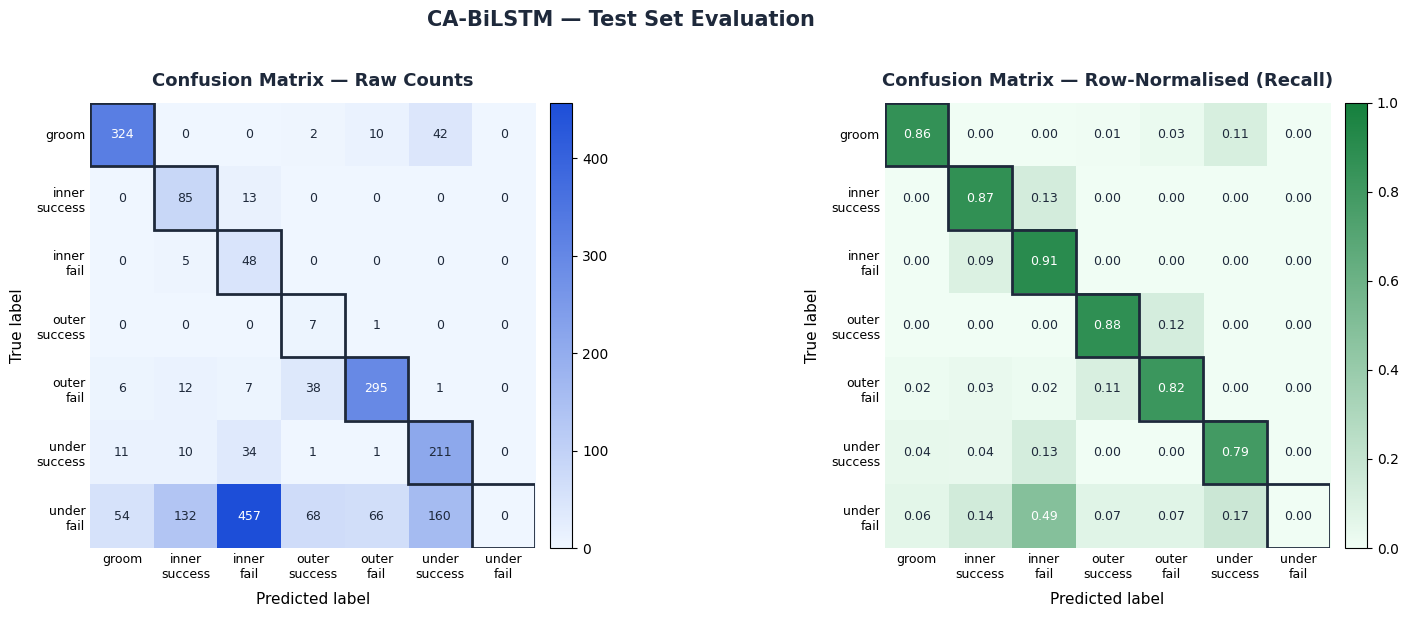

In [8]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 1 — Confusion Matrix (counts + normalised side by side)
# ══════════════════════════════════════════════════════════════════
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
 
cmap_blue  = LinearSegmentedColormap.from_list("blue_cm",  ["#EFF6FF", "#1D4ED8"])
cmap_green = LinearSegmentedColormap.from_list("green_cm", ["#F0FDF4", "#15803D"])
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("white")
 
for ax, data, cmap, fmt, title in [
    (axes[0], cm,      cmap_blue,  "d",    "Confusion Matrix — Raw Counts"),
    (axes[1], cm_norm, cmap_green, ".2f",  "Confusion Matrix — Row-Normalised (Recall)"),
]:
    im = ax.imshow(data, cmap=cmap, vmin=0,
                   vmax=data.max() if fmt == "d" else 1.0)
 
    # Cell text
    thresh = data.max() / 2.0
    for i in range(N_CLASSES):
        for j in range(N_CLASSES):
            val = data[i, j]
            txt = format(val, fmt)
            color = "white" if val > thresh else SLATE
            ax.text(j, i, txt, ha="center", va="center",
                    fontsize=9, fontweight="500", color=color)
 
    # Highlight diagonal
    for k in range(N_CLASSES):
        ax.add_patch(mpatches.Rectangle(
            (k - 0.5, k - 0.5), 1, 1,
            linewidth=2, edgecolor=SLATE, facecolor="none"
        ))
 
    plt.colorbar(im, ax=ax, fraction=0.04, pad=0.02)
    ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
    ax.set_xticklabels(SHORT_NAMES, fontsize=9)
    ax.set_yticklabels(SHORT_NAMES, fontsize=9)
    ax.set_xlabel("Predicted label", fontsize=11, labelpad=8)
    ax.set_ylabel("True label",      fontsize=11, labelpad=8)
    ax.set_title(title, fontsize=13, fontweight="600", pad=12, color=SLATE)
    ax.tick_params(length=0)
    for spine in ax.spines.values():
        spine.set_visible(False)
 
fig.suptitle("CA-BiLSTM — Test Set Evaluation", fontsize=15,
             fontweight="700", color=SLATE, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], "confusion_matrix.png"),
            dpi=150, bbox_inches="tight")
plt.show()

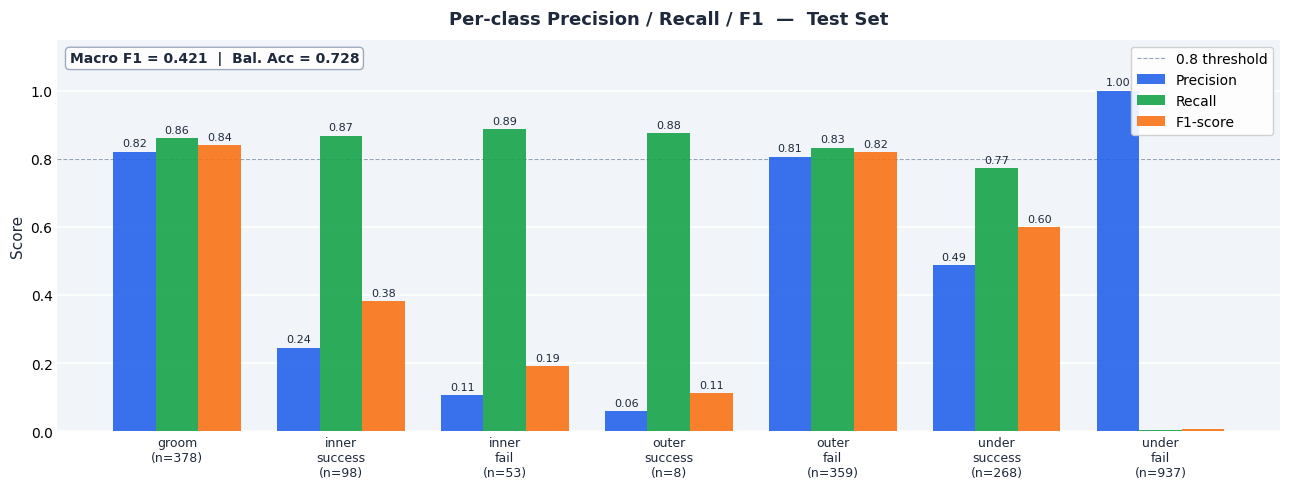

In [15]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 2 — Per-class Precision / Recall / F1 bar chart
# ══════════════════════════════════════════════════════════════════
from sklearn.metrics import precision_recall_fscore_support
 
prec, rec, f1, support = precision_recall_fscore_support(
    labels, preds, labels=list(range(N_CLASSES)), zero_division=0
)
 
x      = np.arange(N_CLASSES)
width  = 0.26
 
fig, ax = plt.subplots(figsize=(13, 5))
fig.patch.set_facecolor("white")
ax.set_facecolor(LIGHT_GREY)
 
bars_p = ax.bar(x - width, prec, width, label="Precision",
                color=BLUE,   alpha=0.9, zorder=3)
bars_r = ax.bar(x,          rec,  width, label="Recall",
                color=GREEN,  alpha=0.9, zorder=3)
bars_f = ax.bar(x + width,  f1,   width, label="F1-score",
                color=ORANGE, alpha=0.9, zorder=3)
 
# Value labels on bars
for bars in [bars_p, bars_r, bars_f]:
    for bar in bars:
        h = bar.get_height()
        if h > 0.02:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.01,
                    f"{h:.2f}", ha="center", va="bottom",
                    fontsize=8, color=SLATE, fontweight="500")
 
# Support counts below x-axis labels
xtick_labels = [f"{SHORT_NAMES[i]}\n(n={support[i]})"
                for i in range(N_CLASSES)]
 
ax.set_xticks(x)
ax.set_xticklabels(xtick_labels, fontsize=9, color=SLATE)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score", fontsize=11, color=SLATE)
ax.set_title("Per-class Precision / Recall / F1  —  Test Set",
             fontsize=13, fontweight="600", color=SLATE, pad=12)
ax.axhline(0.8, color=MID_GREY, linestyle="--", linewidth=0.8,
           zorder=2, label="0.8 threshold")
ax.legend(fontsize=10, framealpha=0.9, loc="upper right")
ax.tick_params(axis="y", length=0)
ax.tick_params(axis="x", length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.yaxis.grid(True, color="white", linewidth=1.2, zorder=1)
 
# Macro F1 annotation
macro_f1 = f1.mean()
ax.text(0.01, 0.97, f"Macro F1 = {macro_f1:.3f}  |  Bal. Acc = {t_bal:.3f}",
        transform=ax.transAxes, fontsize=10, color=SLATE,
        va="top", fontweight="600",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                  edgecolor=MID_GREY, alpha=0.9))
 
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], "per_class_metrics.png"),
            dpi=150, bbox_inches="tight")
plt.show()

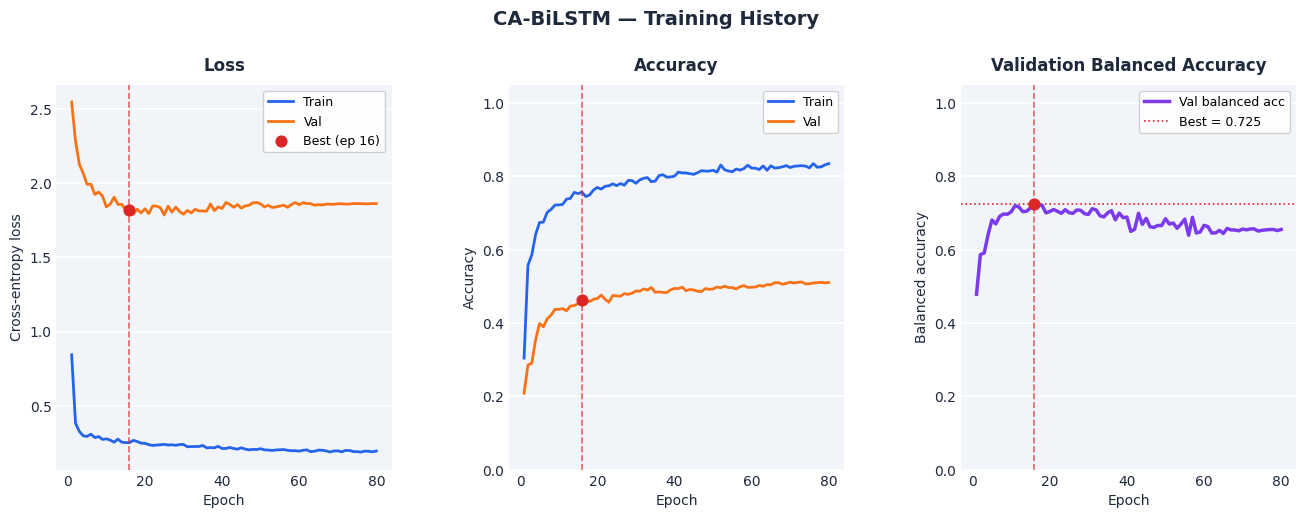

In [16]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 3 — Training curves (loss + accuracy + balanced accuracy)
# ══════════════════════════════════════════════════════════════════
if has_history:
    epochs  = list(range(1, len(history['train_loss']) + 1))
    best_ep = ckpt['epoch']
 
    fig = plt.figure(figsize=(16, 5))
    fig.patch.set_facecolor("white")
    gs  = gridspec.GridSpec(1, 3, wspace=0.35)
 
    # ── subplot helper ────────────────────────────────────────────
    def _style_ax(ax, title, ylabel):
        ax.set_facecolor(LIGHT_GREY)
        ax.set_title(title, fontsize=12, fontweight="600",
                     color=SLATE, pad=10)
        ax.set_xlabel("Epoch", fontsize=10, color=SLATE)
        ax.set_ylabel(ylabel, fontsize=10, color=SLATE)
        ax.tick_params(length=0, labelcolor=SLATE)
        for sp in ax.spines.values(): sp.set_visible(False)
        ax.yaxis.grid(True, color="white", linewidth=1.2, zorder=1)
        ax.axvline(best_ep, color=RED, linestyle="--",
                   linewidth=1.2, zorder=4, alpha=0.7)
        ax.legend(fontsize=9, framealpha=0.9)
 
    # Loss
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(epochs, history['train_loss'], color=BLUE,
             lw=2, label="Train", zorder=3)
    ax1.plot(epochs, history['val_loss'],   color=ORANGE,
             lw=2, label="Val",   zorder=3)
    ax1.scatter([best_ep], [history['val_loss'][best_ep-1]],
                color=RED, s=60, zorder=5, label=f"Best (ep {best_ep})")
    _style_ax(ax1, "Loss", "Cross-entropy loss")
 
    # Accuracy
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(epochs, history['train_acc'], color=BLUE,
             lw=2, label="Train", zorder=3)
    ax2.plot(epochs, history['val_acc'],   color=ORANGE,
             lw=2, label="Val",   zorder=3)
    ax2.scatter([best_ep], [history['val_acc'][best_ep-1]],
                color=RED, s=60, zorder=5)
    ax2.set_ylim(0, 1.05)
    _style_ax(ax2, "Accuracy", "Accuracy")
 
    # Balanced Accuracy
    ax3 = fig.add_subplot(gs[2])
    ax3.plot(epochs, history['val_bal_acc'], color=PURPLE,
             lw=2.5, label="Val balanced acc", zorder=3)
    ax3.axhline(ckpt['val_bal_acc'], color=RED, linestyle=":",
                linewidth=1.2, label=f"Best = {ckpt['val_bal_acc']:.3f}")
    ax3.scatter([best_ep], [ckpt['val_bal_acc']],
                color=RED, s=60, zorder=5)
    ax3.set_ylim(0, 1.05)
    _style_ax(ax3, "Validation Balanced Accuracy",
              "Balanced accuracy")
 
    fig.suptitle("CA-BiLSTM — Training History",
                 fontsize=14, fontweight="700", color=SLATE, y=1.03)
    plt.savefig(os.path.join(CONFIG['save_dir'], "training_curves.png"),
                dpi=150, bbox_inches="tight")
    plt.show()

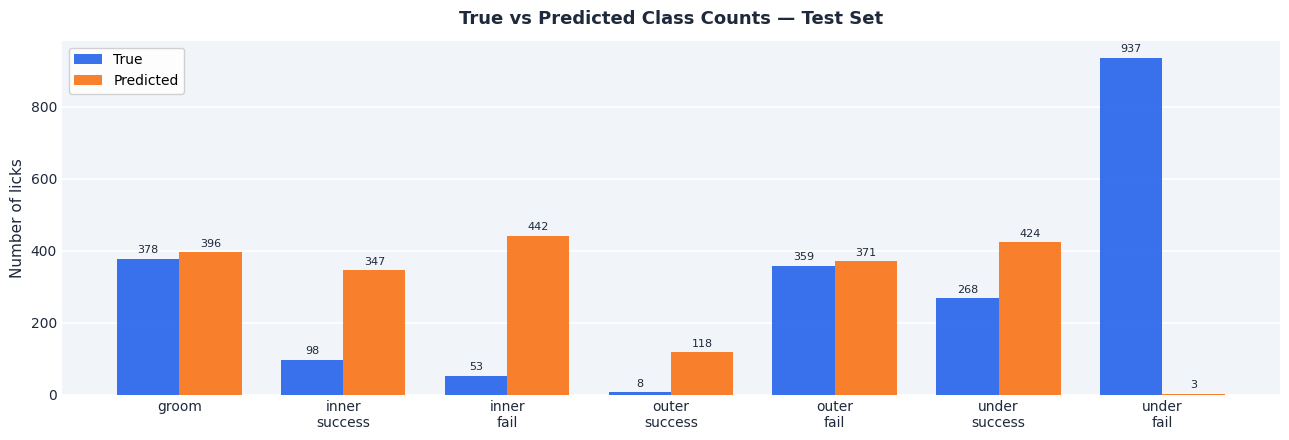

In [17]:
# ══════════════════════════════════════════════════════════════════
# FIGURE 4 — Class distribution: true vs predicted (bar)
# ══════════════════════════════════════════════════════════════════
true_counts = np.bincount(labels, minlength=N_CLASSES)
pred_counts = np.bincount(preds,  minlength=N_CLASSES)
 
x     = np.arange(N_CLASSES)
width = 0.38
 
fig, ax = plt.subplots(figsize=(13, 4.5))
fig.patch.set_facecolor("white")
ax.set_facecolor(LIGHT_GREY)
 
ax.bar(x - width/2, true_counts, width, label="True",
       color=BLUE,   alpha=0.9, zorder=3)
ax.bar(x + width/2, pred_counts, width, label="Predicted",
       color=ORANGE, alpha=0.9, zorder=3)
 
for i, (tc, pc) in enumerate(zip(true_counts, pred_counts)):
    ax.text(i - width/2, tc + max(true_counts)*0.01,
            str(tc), ha="center", va="bottom",
            fontsize=8, color=SLATE, fontweight="500")
    ax.text(i + width/2, pc + max(true_counts)*0.01,
            str(pc), ha="center", va="bottom",
            fontsize=8, color=SLATE, fontweight="500")
 
ax.set_xticks(x)
ax.set_xticklabels(SHORT_NAMES, fontsize=10, color=SLATE)
ax.set_ylabel("Number of licks", fontsize=11, color=SLATE)
ax.set_title("True vs Predicted Class Counts — Test Set",
             fontsize=13, fontweight="600", color=SLATE, pad=12)
ax.legend(fontsize=10, framealpha=0.9)
ax.tick_params(length=0, labelcolor=SLATE)
for sp in ax.spines.values(): sp.set_visible(False)
ax.yaxis.grid(True, color="white", linewidth=1.2, zorder=1)
 
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['save_dir'], "class_distribution.png"),
            dpi=150, bbox_inches="tight")
plt.show()

**SVM**

In [9]:
# ═══════════════════════════════════════════════════════════════
# SVM BASELINE — uses same data as BiLSTM, just flattened
# ═══════════════════════════════════════════════════════════════
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler as SKScaler
from sklearn.metrics import (balanced_accuracy_score,
                             classification_report, confusion_matrix)

# ── Extract raw arrays from datasets ───────────────────────────
# train_ds / val_ds / test_ds hold the same X already normalised
# Combine train+val for SVM (it doesn't need a val set)
X_tr_raw = train_ds.X.numpy()   # (n_train, T, C)
X_te_raw = test_ds.X.numpy()    # (n_test,  T, C)
y_tr_svm = train_ds.y.numpy()
y_te_svm = test_ds.y.numpy()

# ── Flatten (T, C) → (T*C,) per lick ──────────────────────────
# Shape becomes (n_licks, T*C) = (n_licks, 270)
X_tr_flat = X_tr_raw.reshape(len(X_tr_raw), -1)
X_te_flat = X_te_raw.reshape(len(X_te_raw), -1)

print(f"SVM input shape — train: {X_tr_flat.shape}, test: {X_te_flat.shape}")

# ── Train SVM ──────────────────────────────────────────────────
print("Training SVM (this may take ~1-2 min)...")
svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced',
    random_state=42,
    probability=False,
)
svm.fit(X_tr_flat, y_tr_svm)

# ── Evaluate ───────────────────────────────────────────────────
svm_preds = svm.predict(X_te_flat)
svm_acc   = (svm_preds == y_te_svm).mean()
svm_bal   = balanced_accuracy_score(y_te_svm, svm_preds)

print(f"\nSVM Results:")
print(f"  Test Accuracy          : {svm_acc:.4f}")
print(f"  Test Balanced Accuracy : {svm_bal:.4f}")
print()
print(classification_report(y_te_svm, svm_preds,
                            target_names=LABEL_NAMES,
                            zero_division=0))

# Store for comparison table at end
svm_results = {'acc': svm_acc, 'bal': svm_bal, 'preds': svm_preds}

SVM input shape — train: (9800, 270), test: (2101, 270)
Training SVM (this may take ~1-2 min)...

SVM Results:
  Test Accuracy          : 0.7254
  Test Balanced Accuracy : 0.6266

                    precision    recall  f1-score   support

             groom       0.83      0.85      0.84       378
inner_tube_success       0.41      0.69      0.51        98
   inner_tube_fail       0.25      0.32      0.28        53
outer_edge_success       0.29      0.25      0.27         8
   outer_edge_fail       0.84      0.91      0.88       359
under_tube_success       0.54      0.73      0.62       268
   under_tube_fail       0.82      0.63      0.71       937

          accuracy                           0.73      2101
         macro avg       0.57      0.63      0.59      2101
      weighted avg       0.75      0.73      0.73      2101



In [10]:
# ═══════════════════════════════════════════════════════════════
# FINAL COMPARISON TABLE
# ═══════════════════════════════════════════════════════════════
print("=" * 50)
print(f"{'Model':<20} {'Bal. Acc':>10} {'Accuracy':>10}")
print("=" * 50)
print(f"{'SVM (RBF)':<20} {svm_results['bal']*100:>9.2f}% {svm_results['acc']*100:>9.2f}%")
print(f"{'CA-BiLSTM':<20} {t_bal*100:>9.2f}% {t_acc*100:>9.2f}%")
print("=" * 50)
print("\nPrimary metric: Balanced Accuracy")
print("(Raw accuracy misleading due to class imbalance)")

Model                  Bal. Acc   Accuracy
SVM (RBF)                62.66%     72.54%
CA-BiLSTM                73.06%     46.17%

Primary metric: Balanced Accuracy
(Raw accuracy misleading due to class imbalance)
